In [1]:
import os, glob, copy
import numpy as np
import nrrd, scipy
import matplotlib.pyplot as plt
import orn_pn_matching_imaging as im
import orn_pn_matching as opm
import plotting_help_py37 as ph
from skimage import measure
import matplotlib.gridspec as gridspec
from matplotlib import animation
from IPython import display
import matplotlib as mpl 
from scipy import ndimage
from matplotlib import rcParams

mpl.rcParams['animation.ffmpeg_path'] = '../ffmpeg'
rcParams['text.usetex'] = True
plt.rcParams.update({'text.usetex': True})
import warnings
warnings.filterwarnings("ignore")

In [2]:
im.plot_bars

<function orn_pn_matching_imaging.plot_bars(gts, ax, **kwargs)>

In [3]:
import os, re, csv
import SimpleITK as sitk

In [4]:
%pylab inline
%load_ext autoreload
%autoreload 2

Populating the interactive namespace from numpy and matplotlib


In [63]:
gt = 'DA1_v-ConX'
recs = im.get_recs_BinaryAL(genotype=gt, parent_folder=im.gt2pf[gt], csv_first=False)

In [64]:
im.gt2pf[gt]

'../../../1_Data/confocal/2_ORN_exps/TT/TT-DA1_ORN/TT-DA1_v-TenaRNAi-FiliOE-kek1OE-Ptp10DRNAi/'

In [65]:
len(recs)

6

In [66]:
ys = []
for rec in recs:
    ys.append(rec.overlap_ORN)
ys = np.array(ys)

In [67]:
mean(ys)

46.6802988897548

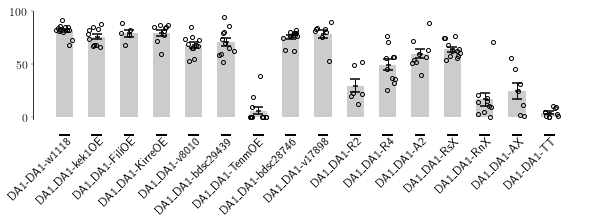

In [5]:
gts_DA1 = ['DA1-DA1-w1118', 
           'DA1_DA1-kek1OE', 'DA1_DA1-FiliOE', 'DA1_DA1-KirreOE', 
           'DA1_DA1-v8010',
           'DA1_DA1-bdsc29439', 'DA1_DA1-TenmOE', 'DA1_DA1-bdsc28746', 'DA1_DA1-v17898', 
           'DA1_DA1-R2', 'DA1_DA1-R4', 'DA1_DA1-A2', 'DA1_DA1-RsX', 'DA1_DA1-RnX', 'DA1_DA1-AX', 
           'DA1-DA1-TT',]
ax = ph.large_ax([10,2])
yss = im.plot_bars(gts_DA1, ax, col_width=.4, group_gap=.35, ms_indi=4,)
# ph.save('TT-steps-DA1-DA1', exts=['pdf',])

In [12]:
t_stat, p_value = ttest_ind(yss[-1]*0,yss[-1], alternative='less')
print(f'Paired T-Test: p-value = {p_value:.7f}')
t_stat, p_value = f_oneway(yss[-1]*0,yss[-1])
print(f'Paired T-Test: p-value = {p_value:.7f}')

Paired T-Test: p-value = 0.0017742
Paired T-Test: p-value = 0.0035484


In [11]:
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
for i in range(len(yss)):
    # Perform the paired t-test
#     t_stat, p_value = ttest_ind(yss[0],yss[i], alternative='greater')
    t_stat, p_value = ttest_ind(yss[0],yss[i], alternative='greater')
    print(f'Paired T-Test: p-value = {p_value:.7f}')

Paired T-Test: p-value = 0.5000000
Paired T-Test: p-value = 0.0306521
Paired T-Test: p-value = 0.2082471
Paired T-Test: p-value = 0.2656288
Paired T-Test: p-value = 0.0001017
Paired T-Test: p-value = 0.0062853
Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0128284
Paired T-Test: p-value = 0.2084955
Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0000011
Paired T-Test: p-value = 0.0000253
Paired T-Test: p-value = 0.0000007
Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0000000


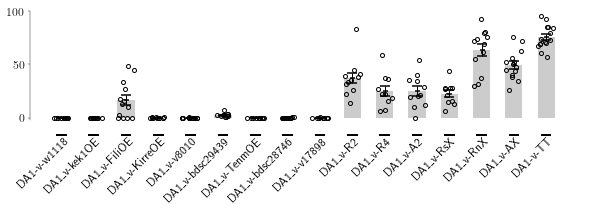

In [50]:
gts_v = ['DA1-v-w1118', 
         'DA1_v-kek1OE', 'DA1_v-FiliOE', 'DA1_v-KirreOE', 
         'DA1_v-v8010',
         'DA1_v-bdsc29439', 'DA1_v-TenmOE', 'DA1_v-bdsc28746', 'DA1_v-v17898',
         'DA1_v-R2', 'DA1_v-R4', 'DA1_v-A2', 'DA1_v-RsX', 'DA1_v-RnX', 'DA1_v-AX', 
         'DA1-v-TT',]
ax = ph.large_ax([10,2])
xss = im.plot_bars(gts_v, ax, col_width=.4, group_gap=.35, ms_indi=4,)
# ph.save('TT-steps-DA1-v', exts=['pdf',])

In [51]:
from scipy.stats import ttest_ind
for i in range(len(xss)):
    # Perform the paired t-test
    t_stat, p_value = ttest_ind(xss[0],xss[i], alternative='less')
    print(f'Paired T-Test: p-value = {p_value:.7f}')

Paired T-Test: p-value = 0.5000000
Paired T-Test: p-value = 0.8232739
Paired T-Test: p-value = 0.0023947
Paired T-Test: p-value = 0.0233512
Paired T-Test: p-value = 0.1684685
Paired T-Test: p-value = 0.0001725
Paired T-Test: p-value = 0.8232739
Paired T-Test: p-value = 0.0755434
Paired T-Test: p-value = 0.1213808
Paired T-Test: p-value = 0.0000004
Paired T-Test: p-value = 0.0000226
Paired T-Test: p-value = 0.0000140
Paired T-Test: p-value = 0.0000005
Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0000000


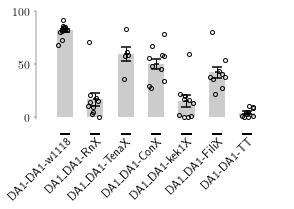

In [40]:
gts_DA1 = ['DA1-DA1-w1118', 'DA1_DA1-RnX', 'DA1_DA1-TenaX', 'DA1_DA1-ConX', 'DA1_DA1-kek1X', 'DA1_DA1-FiliX',
           'DA1-DA1-TT',]
ax = ph.large_ax([4.5,2])
xss = im.plot_bars(gts_DA1, ax, col_width=.4, group_gap=.35, ms_indi=4,)
# ph.save('TT-5-DA1-DA1', exts=['pdf',])

In [41]:
from scipy.stats import ttest_ind
for i in range(len(xss)):
    # Perform the paired t-test
    t_stat, p_value = ttest_ind(xss[-1],xss[i], alternative='less')
    print(f'Paired T-Test: p-value = {p_value:.7f}')

Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0360834
Paired T-Test: p-value = 0.0000001
Paired T-Test: p-value = 0.0000001
Paired T-Test: p-value = 0.0396656
Paired T-Test: p-value = 0.0000013
Paired T-Test: p-value = 0.5000000


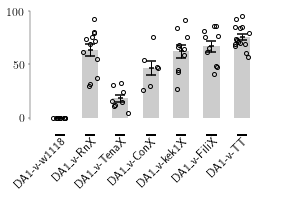

In [45]:
gts_DA1 = ['DA1-v-w1118', 'DA1_v-RnX', 'DA1_v-TenaX', 'DA1_v-ConX', 'DA1_v-kek1X', 'DA1_v-FiliX',
           'DA1-v-TT',]
ax = ph.large_ax([4.5,2])
xss = im.plot_bars(gts_DA1, ax, col_width=.4, group_gap=.35, ms_indi=4,)
# ph.save('TT-5-DA1-v', exts=['pdf',])

In [46]:
from scipy.stats import ttest_ind
for i in range(len(xss)):
    # Perform the paired t-test
    t_stat, p_value = ttest_ind(xss[-1],xss[i], alternative='greater')
    print(f'Paired T-Test: p-value = {p_value:.7f}')

Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0288819
Paired T-Test: p-value = 0.0000000
Paired T-Test: p-value = 0.0001236
Paired T-Test: p-value = 0.0225579
Paired T-Test: p-value = 0.0684801
Paired T-Test: p-value = 0.5000000


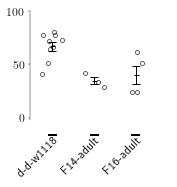

In [35]:
gts = ['d-d-w1118', 'F14-adult', 'F16-adult']
ax = ph.large_ax([2.5,2])
im.plot_bars(gts, ax, gt2pf)
ph.save('F14-adult-bar', exts=['pdf',])

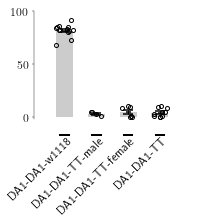

In [7]:
gts_DA1 = ['DA1-DA1-w1118', 
           'DA1-DA1-TT-male','DA1-DA1-TT-female','DA1-DA1-TT']
ax = ph.large_ax([3,2])
yss = im.plot_bars(gts_DA1, ax, col_width=.4, group_gap=.35, ms_indi=4,)
ph.save('TT-steps-DA1-DA1-TT-mf', exts=['pdf',])

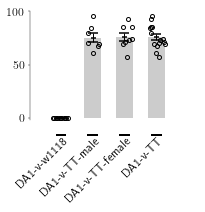

In [8]:
gts_DA1 = ['DA1-v-w1118', 
           'DA1-v-TT-male','DA1-v-TT-female','DA1-v-TT']
ax = ph.large_ax([3,2])
yss = im.plot_bars(gts_DA1, ax, col_width=.4, group_gap=.35, ms_indi=4,)
ph.save('TT-steps-DA1-v-TT-mf', exts=['pdf',])

## TT Male Female

## Doodle

In [5]:
gts_v = ['DA1-v-w1118', 
         'DA1_v-kek1OE', 'DA1_v-FiliOE', 'DA1_v-18wOE', 'DA1_v-KirreOE', 
         'DA1_v-v8010',
         'DA1_v-bdsc29439', 'DA1_v-TenmOE', 'DA1_v-bdsc28746', 'DA1_v-v17898',
         'DA1_v-R2', 'DA1_v-R4', 'DA1_v-A2', 'DA1_v-RsX', 'DA1_v-RnX', 'DA1_v-AX', 
         'DA1-v-TT',]

In [43]:
xss = []
for i, gt in enumerate(gts_v):
    recs = im.get_recs_BinaryAL(genotype=gt, parent_folder=im.gt2pf[gt], csv_first=True)
    ys = []
    for rec in recs:
        ys.append(rec.overlap_ORN)
    ys = np.array(ys)
    xss.append(ys)

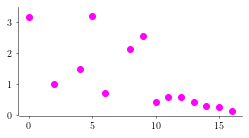

In [44]:
cvs = []   # coefficient of variation
for xs in xss:
    cv = np.std(xs) / np.nanmean(xs)
    cvs.append(cv)
cvs = np.array(cvs)
ax = ph.large_ax([4,2])
ax.plot(cvs, ls='none',marker='o',color='magenta')
ph.adjust_spines(ax, ['left','bottom'], ylim=[0,3.5],yticks=[0,1,2,3])
ph.save('coefV-DA1-v', exts=['pdf',])

In [34]:
gts_DA1 = ['DA1-DA1-w1118', 
           'DA1_DA1-kek1OE', 'DA1_DA1-FiliOE', 'DA1_DA1-18wOE', 'DA1_DA1-KirreOE', 
           'DA1_DA1-v8010',
           'DA1_DA1-bdsc29439', 'DA1_DA1-TenmOE', 'DA1_DA1-bdsc28746', 'DA1_DA1-v17898', 
           'DA1_DA1-R2', 'DA1_DA1-R4', 'DA1_DA1-A2', 'DA1_DA1-RsX', 'DA1_DA1-RnX', 'DA1_DA1-AX', 
           'DA1-DA1-TT',]

In [45]:
xss = []
for i, gt in enumerate(gts_DA1):
    recs = im.get_recs_BinaryAL(genotype=gt, parent_folder=im.gt2pf[gt], csv_first=True)
    ys = []
    for rec in recs:
        ys.append(rec.overlap_ORN)
    ys = np.array(ys)
    xss.append(ys)

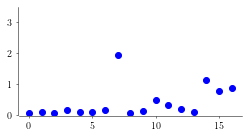

In [46]:
cvs = []   # coefficient of variation
for xs in xss:
    cv = np.std(xs) / np.nanmean(xs)
    cvs.append(cv)
cvs = np.array(cvs)
ax = ph.large_ax([4,2])
ax.plot(cvs, ls='none',marker='o',color='blue')
ph.adjust_spines(ax, ['left','bottom'], ylim=[0,3.5],yticks=[0,1,2,3])
ph.save('coefV-DA1-DA1', exts=['pdf',])

In [10]:
xs = xss[10]

In [12]:
np.std(xs) / np.nanmean(xs)

0.44867095515061967